# Multi-Output Regression for ML-CUP25 Using Machine Learning Models

**Course:** Machine Learning  
**University:** University of Pisa  
**Students:** Nandani Kathiriya, Laiba Khalid

# Project Type

This project follows the Type B ML project paradigm described in the ML Course guidelines.

The project focuses on the experimental comparison and validation of machine learning models implemented using the scikit-learn framework rather than on developing learning algorithms from scratch.

The work includes:
- model comparison,
- hyperparameter optimization,
- validation methodology,
- overfitting analysis,
- model selection,
- and experimental evaluation on the ML CUP 2025 dataset.

The evaluated models include:
- Linear Regression
- Random Forest Regressor
- Multi-Layer Perceptron (MLP)
- Support Vector Regression (SVR)

The final selected model is used to generate predictions for the blind ML CUP 2025 test set.

## 1. Import Libraries and Setup Paths

We import required libraries and define paths for dataset loading and result storage.

In [1]:
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
import time
np.random.seed(42)  # Fixed seed for reproducibility across experiments

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

data_dir = os.path.join(project_root, "data", "cup")
results_dir = os.path.join(project_root, "results", "cup")

os.makedirs(results_dir, exist_ok=True)   # Create results directory if it does not already exist

train_path = os.path.join(data_dir, "ML-CUP25-TR.csv")
test_path = os.path.join(data_dir, "ML-CUP25-TS.csv")

import warnings

# Suppress known sklearn parallelization warning

warnings.filterwarnings(
    "ignore",
    message=".*sklearn.utils.parallel.delayed.*"
)

## 2. Load Dataset

The CUP dataset is structured as follows:
- Column 0: sample ID (ignored)
- Columns 1–12: input features
- Columns 13–16: target values (4 outputs)

This is a multi-output regression problem.

The test dataset does not include target values, so it is used only for final predictions.

In [2]:
train_df = pd.read_csv(train_path, comment="#", header=None)
test_df = pd.read_csv(test_path, comment="#", header=None)

X = train_df.iloc[:, 1:13].values # first 12 columns are features, last 4 columns are targets
Y = train_df.iloc[:, 13:17].values

X_test_blind = test_df.iloc[:, 1:13].values  # Blind test set has no target values

## 2.1 Reproducibility

All experiments were performed using Python and scikit-learn.

Random seeds (`random_state=42`) and fixed train/validation/test splits were used to improve reproducibility.

Preprocessing operations were included inside `Pipeline` objects to prevent data leakage during cross-validation.

## 3. Train / Validation / Test Split

The ML-CUP25 dataset contains only 500 labeled samples. Therefore, most of the available data is allocated to training in order to maximize the information available for model fitting.

The dataset is divided into:
- Training set (80%) → used for model training and hyperparameter optimization through cross-validation
- Validation set (10%) → used only for post-selection comparison and qualitative analysis of candidate models
- Internal Test set (10%) → reserved as an independent hold-out test set for final internal hold-out evaluation

Hyperparameter optimization was performed exclusively through 5-fold cross-validation on the training set using `GridSearchCV`.

The internal test set remained completely isolated until the final evaluation stage. This separation reduces the risk of information leakage and provides a more reliable estimate of generalization performance.

This strategy combines:
- cross-validation for robust model selection,
- a validation set for additional independent comparison,
- and a completely unseen internal test set for final assessment.

In [3]:
# First split: isolate completely unseen internal test set
X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

# First split: isolate completely unseen internal test set
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full,
    Y_train_full,
    # 0.1111 of remaining 90% ≈ 10% of full dataset
    test_size=0.1111,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 400
Validation size: 50
Test size: 50


## 3.1 Validation Methodology Summary

The validation workflow used in this project is summarized below:

1. The original ML-CUP25 dataset was divided into:
   - Training set (80%)
   - Validation set (10%)
   - Internal test set (10%)

2. Hyperparameter optimization was performed exclusively through 5-fold cross-validation on the training set using `GridSearchCV`.

3. The validation set was used only for secondary post-selection comparison and qualitative analysis of candidate models.

4. The internal test set remained completely isolated during model development and was used only once for the final internal evaluation.

5. After selecting the final model configuration, the selected model was retrained on the complete labeled dataset before generating blind test predictions.

## 4. Feature Scaling

Feature scaling was applied only to SVR and MLP because these models are sensitive to feature magnitude.

Random Forest was trained without scaling since tree-based methods are naturally scale-invariant.

Scaling was included inside `Pipeline` objects to avoid data leakage during cross-validation.

## 5. Evaluation Metric

We use Mean Euclidean Error (MEE) as the evaluation metric.

MEE measures the average Euclidean distance between predicted and true target vectors across all samples.

Lower MEE values indicate better predictive performance.

For a dataset containing \( l \) samples and \( m \) output dimensions, the Mean Euclidean Error is defined as:

$$
E_{MEE} = \frac{1}{l} \sum_{p=1}^{l}
\sqrt{
\sum_{j=1}^{m}
\left(y_{pj} - \hat{y}_{pj}\right)^2
}
$$

where:
- \( y_{pj} \) denotes the true target value for output dimension \( j \) of sample \( p \),
- \( \hat{y}_{pj} \) denotes the corresponding predicted value,
- \( l \) is the number of samples,
- and \( m \) is the number of output dimensions.

In [4]:
import numpy as np

# Mean Euclidean Error used in official ML-CUP evaluation
def mee(y_true, y_pred):
    return np.mean(np.sqrt(np.sum((y_true - y_pred) ** 2, axis=1)))

from sklearn.metrics import make_scorer

mee_scorer = make_scorer(mee, greater_is_better=False)

MEE was selected because it jointly evaluates prediction error across all output dimensions while preserving the geometric structure of the multi-output regression task.

## 6. Baseline Models

In the baseline phase, several machine learning paradigms are evaluated in order to compare different approaches to multi-output regression:

- Linear Regression (linear model)
- SVR (kernel-based method)
- Random Forest (ensemble tree method)
- MLP (neural network)

StandardScaler is applied only to models that are sensitive to feature magnitude, including MLP, SVR. Tree-based ensemble methods are naturally scale-invariant and therefore use the original feature representation.

Pipelines are used to ensure that preprocessing and model training are performed consistently and without data leakage during cross-validation and evaluation.

In [5]:
from sklearn.linear_model import LinearRegression

# Compare different regression paradigms before tuning
baseline_models = {

    "Linear Regression": LinearRegression(),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(SVR()))
    ]),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        oob_score=True   # oob_score enabled for additional ensemble diagnostics
    ),

    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            max_iter=10000,  # Large max_iter used to avoid premature convergence stopping
            random_state=42
        ))
    ]),
}

pd.options.display.float_format = '{:.4f}'.format

baseline_results = []

# Train and evaluate each baseline model
for name, model in baseline_models.items():

    model.fit(X_train, Y_train)

    baseline_results.append({
        "Model": name,
        "Train MEE": mee(
            Y_train,
            model.predict(X_train)
        ),
        "Validation MEE": mee(
            Y_val,
            model.predict(X_val)
        ),
    })

baseline_df = pd.DataFrame(
    baseline_results
).sort_values("Validation MEE")

display(baseline_df)

for result in baseline_results:
    gap = result["Validation MEE"] - result["Train MEE"]

    print(
        f"{result['Model']:20s}"
        f" | Train: {result['Train MEE']:.4f}"
        f" | Val: {result['Validation MEE']:.4f}"
        f" | Gap: {gap:.4f}"
    )

,Model,Train MEE,Validation MEE
2,Random Forest,7.7382,19.4743
3,MLP,17.5207,19.8481
0,Linear Regression,25.0467,25.1338
1,SVR,25.0297,25.2784


Linear Regression    | Train: 25.0467 | Val: 25.1338 | Gap: 0.0871
SVR                  | Train: 25.0297 | Val: 25.2784 | Gap: 0.2486
Random Forest        | Train: 7.7382 | Val: 19.4743 | Gap: 11.7361
MLP                  | Train: 17.5207 | Val: 19.8481 | Gap: 2.3275


The baseline experiments revealed substantial differences in predictive performance and generalization behavior across the evaluated models.

Linear Regression and SVR achieved the weakest validation performance, indicating limited capability in modeling the nonlinear relationships present in the dataset.

Random Forest achieved strong predictive performance but exhibited noticeable overfitting due to the larger train-validation gap.

MLP obtained the strongest baseline validation performance among the evaluated models while maintaining a relatively small gap between training and validation error, suggesting better robustness compared to the other evaluated approaches.

Based on the baseline experiments, MLP emerged as the most promising model and was therefore selected for further hyperparameter optimization.

## 7. Hyperparameter Tuning

We use GridSearchCV with 5-fold cross-validation to select optimal parameters.

In [6]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt", "log2"]
}

# Exhaustive hyperparameter search using 5-fold CV
rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        oob_score=True
    ),
    rf_param_grid,
    scoring=mee_scorer,
    cv=5,
    n_jobs=-1
)

rf_start = time.time()

rf_grid.fit(X_train, Y_train)

rf_time = time.time() - rf_start

best_rf = rf_grid.best_estimator_

print("Best CV MEE:")
print(-rf_grid.best_score_)

# Scaling included inside pipeline to avoid data leakage
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        max_iter=10000,
        random_state=42,
        early_stopping=True
    ))
])

mlp_param_grid = {
    "model__hidden_layer_sizes": [
        (50,),
        (100,),
        (200, 200),
        (250, 300, 200)
    ],
    "model__alpha": [
        0.0001,
        0.001
    ],
    "model__learning_rate_init": [
        0.001,
        0.01
    ]
}

mlp_grid = GridSearchCV(
    mlp_pipeline,
    mlp_param_grid,
    scoring=mee_scorer,
    cv=5,
    n_jobs=-1
)

mlp_start = time.time()

mlp_grid.fit(X_train, Y_train)

mlp_time = time.time() - mlp_start

print(f"Total configs: {4 * 2 * 2} configurations")
print(f"Total fits: {4 * 2 * 2 * 5} (x5 folds)")

print("\nBest Parameters Found:")

print(f"  Hidden layers : {mlp_grid.best_params_['model__hidden_layer_sizes']}")
print(f"  Alpha         : {mlp_grid.best_params_['model__alpha']}")
print(f"  Learning rate : {mlp_grid.best_params_['model__learning_rate_init']}")
print(f"  Best CV MEE   : {-mlp_grid.best_score_:.4f}")

best_mlp = mlp_grid.best_estimator_

print("Best CV MEE:")
print(-mlp_grid.best_score_)

# MultiOutputRegressor trains one SVR per output dimension
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(SVR()))
])

svr_param_grid = {
    "model__estimator__C": [
        1,
        10
    ],
    "model__estimator__gamma": [
        "scale",
        0.01
    ],
    "model__estimator__kernel": [
        "rbf"
    ]
}

svr_grid = GridSearchCV(
    svr_pipeline,
    svr_param_grid,
    scoring=mee_scorer,
    cv=5,
    n_jobs=-1
)

svr_start = time.time()

svr_grid.fit(X_train, Y_train)

svr_time = time.time() - svr_start

best_svr = svr_grid.best_estimator_

print("Best CV MEE:")
print(-svr_grid.best_score_)

Best CV MEE:
22.281965482616783
Total configs: 16 configurations
Total fits: 80 (x5 folds)

Best Parameters Found:
  Hidden layers : (250, 300, 200)
  Alpha         : 0.001
  Learning rate : 0.01
  Best CV MEE   : 22.1999
Best CV MEE:
22.199863273110765
Best CV MEE:
24.107649239368


## 7.1 Hyperparameter Search Complexity

An extensive grid search strategy was used to investigate the sensitivity of different models to hyperparameter configurations.

For Random Forest, the explored search space included:

* number of trees,
* tree depth,
* minimum split size,
* minimum leaf size,
* and feature subsampling strategies.

The total number of tested Random Forest configurations was:

2 × 3 × 2 × 2 × 2 = 48 configurations

Using 5-fold cross-validation, this required:

48 × 5 = 240 model fits

For MLP, the explored search space included:

* hidden layer architectures,
* regularization strength (`alpha`),
* and learning rate initialization.

The total number of tested MLP configurations was:

4 × 2 × 2 = 16 configurations

Using 5-fold cross-validation, this required:

16 × 5 = 80 model fits

For SVR, the explored search space included:

* regularization parameter (`C`)
* kernel coefficient (`gamma`)
* and RBF kernel configuration.

The total number of tested SVR configurations was:

2 × 2 × 1 = 4 configurations

Using 5-fold cross-validation, this required:

4 × 5 = 20 model fits

Since MultiOutputRegressor trains one SVR model per target dimension, the effective computational cost was higher than standard single-output SVR.

## 7.2 Hyperparameter Sensitivity Analysis


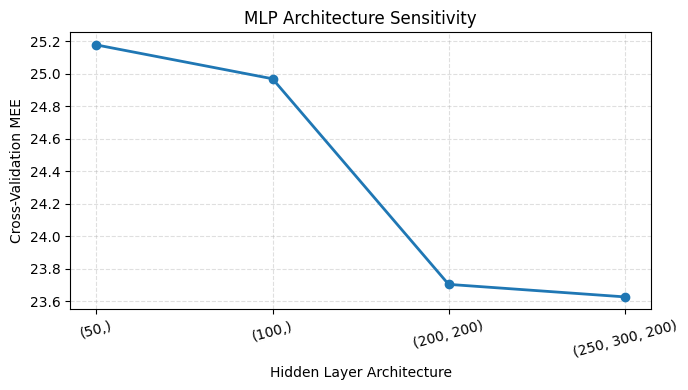

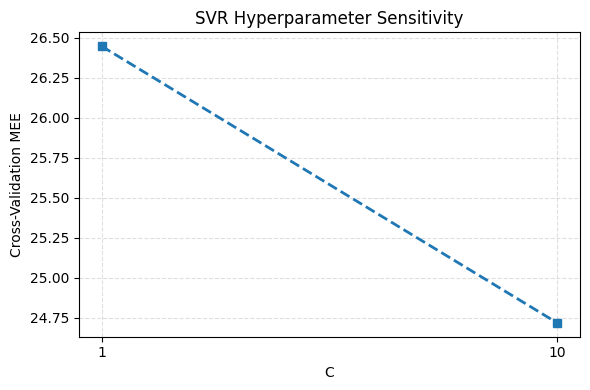

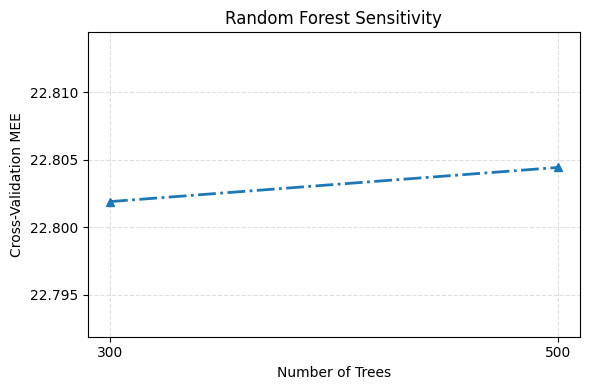

In [7]:
# Analyze how architecture affects validation performance

mlp_results = pd.DataFrame(mlp_grid.cv_results_)

arch_scores = (
    mlp_results.groupby(
        "param_model__hidden_layer_sizes"
    )["mean_test_score"]
    .mean()
)

architectures = [
    str(x) for x in arch_scores.index
]

cv_mee_scores = -arch_scores.values

plt.figure(figsize=(7, 4))

plt.plot(
    architectures,
    cv_mee_scores,
    marker='o',
    linestyle='-',
    linewidth=2
)

plt.xlabel("Hidden Layer Architecture")
plt.ylabel("Cross-Validation MEE")

plt.title("MLP Architecture Sensitivity")

plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "mlp_hyperparameter_sensitivity.png"
    ),
    dpi=300
)

plt.show()

# Analyze effect of SVR regularization parameter
svr_results = pd.DataFrame(svr_grid.cv_results_)

svr_scores = (
    svr_results.groupby(
        "param_model__estimator__C"
    )["mean_test_score"]
    .mean()
)

plt.figure(figsize=(6,4))

plt.plot(
    svr_scores.index.astype(str),
    -svr_scores.values,
    marker='s',
    linestyle='--',
    linewidth=2
)

plt.xlabel("C")
plt.ylabel("Cross-Validation MEE")

plt.title("SVR Hyperparameter Sensitivity")

plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "svr_hyperparameter_sensitivity.png"
    ),
    dpi=300
)

plt.show()

rf_results = pd.DataFrame(rf_grid.cv_results_)

rf_scores = (
    rf_results.groupby(
        "param_n_estimators"
    )["mean_test_score"]
    .mean()
)

rf_cv_scores = -rf_scores.values

plt.figure(figsize=(6,4))

plt.plot(
    rf_scores.index.astype(str),
    rf_cv_scores,
    marker='^',
    linestyle='-.',
    linewidth=2
)

plt.xlabel("Number of Trees")
plt.ylabel("Cross-Validation MEE")

plt.title("Random Forest Sensitivity")

plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

plt.ylim(
    min(rf_cv_scores) - 0.01,
    max(rf_cv_scores) + 0.01
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "rf_hyperparameter_sensitivity.png"
    ),
    dpi=300
)

plt.show()


Different hyperparameter configurations produced noticeably different validation and test performance across the evaluated models.

For Random Forest, deeper trees and weaker regularization generally improved training performance but also increased the risk of overfitting. Increasing the number of trees improved prediction stability, although performance improvements became progressively smaller beyond a certain ensemble size.

For MLP, predictive performance was strongly influenced by network architecture, regularization strength, and learning rate initialization. Larger hidden-layer structures improved nonlinear representation capability, while L2 regularization (`alpha`) and early stopping helped reduce overfitting and improve generalization.

Some MLP configurations also produced less stable validation performance across folds, particularly deeper architectures combined with larger learning rates.

Overall, the experiments showed that model performance was highly dependent on the selected hyperparameters.

Higher C values improved fitting flexibility but also increased sensitivity to variance across folds.

Despite tuning, SVR remained less competitive than MLP on the ML-CUP25 task.


## 7.3 Model Selection Strategy

Model selection was based primarily on 5-fold cross-validation performance obtained during GridSearchCV.

The validation set was used only for additional post-selection comparison, while the internal test set remained isolated until final evaluation.

In [8]:
linear_model = LinearRegression()

linear_model.fit(X_train, Y_train)

linear_val_mee = mee(
    Y_val,
    linear_model.predict(X_val)
)

from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(
    LinearRegression(),
    X_train,
    Y_train,
    scoring=mee_scorer,
    cv=5,
    n_jobs=-1
)

linear_cv_mee = -lr_scores.mean()
linear_cv_std = abs(lr_scores.std())

## 8. Final Model Comparison


In [9]:
rf_best_idx = rf_grid.best_index_
mlp_best_idx = mlp_grid.best_index_
svr_best_idx = svr_grid.best_index_

rf_cv_std = abs(
    rf_grid.cv_results_["std_test_score"][rf_best_idx]
)

mlp_cv_std = abs(
    mlp_grid.cv_results_["std_test_score"][mlp_best_idx]
)

svr_cv_std = abs(
    svr_grid.cv_results_["std_test_score"][svr_best_idx]
)

# Combine all evaluation metrics into a single comparison table
final_comparison_df = pd.DataFrame([

    {
        "Model": "Linear Regression",

        "Train MEE": baseline_df.loc[
            baseline_df["Model"] == "Linear Regression",
            "Train MEE"
        ].values[0],

        "Validation MEE": linear_val_mee,

        "Test MEE": mee(
            Y_test,
            linear_model.predict(X_test)
        ),

        "5-Fold CV MEE ± STD":
            f"{linear_cv_mee:.2f} ± {linear_cv_std:.2f}",

        "CV Mean": linear_cv_mee
    },

    {
        "Model": "SVR",

        "Train MEE": mee(
            Y_train,
            best_svr.predict(X_train)
        ),

        "Validation MEE": mee(
            Y_val,
            best_svr.predict(X_val)
        ),

        "Test MEE": mee(
            Y_test,
            best_svr.predict(X_test)
        ),

        "5-Fold CV MEE ± STD":
            f"{-svr_grid.best_score_:.2f} ± {svr_cv_std:.2f}",

        "CV Mean": -svr_grid.best_score_
    },

    {
        "Model": "Random Forest",

        "Train MEE": mee(
            Y_train,
            best_rf.predict(X_train)
        ),

        "Validation MEE": mee(
            Y_val,
            best_rf.predict(X_val)
        ),

        "Test MEE": mee(
            Y_test,
            best_rf.predict(X_test)
        ),

        "5-Fold CV MEE ± STD":
            f"{-rf_grid.best_score_:.2f} ± {rf_cv_std:.2f}",

        "CV Mean": -rf_grid.best_score_
    },

    {
        "Model": "MLP",

        "Train MEE": mee(
            Y_train,
            best_mlp.predict(X_train)
        ),

        "Validation MEE": mee(
            Y_val,
            best_mlp.predict(X_val)
        ),

        "Test MEE": mee(
            Y_test,
            best_mlp.predict(X_test)
        ),

        "5-Fold CV MEE ± STD":
            f"{-mlp_grid.best_score_:.2f} ± {mlp_cv_std:.2f}",

        "CV Mean": -mlp_grid.best_score_
    }

])

final_comparison_df = final_comparison_df.sort_values(
    by="CV Mean",
    ascending=True
).reset_index(drop=True)

pd.options.display.float_format = "{:.4f}".format

display(
    final_comparison_df.drop(columns=["CV Mean"])
)

,Model,Train MEE,Validation MEE,Test MEE,5-Fold CV MEE ± STD
0,MLP,18.1102,19.5111,20.7990,22.20 ± 1.29
1,Random Forest,11.5497,20.5803,21.8598,22.28 ± 1.05
2,SVR,22.5228,23.1405,25.0927,24.11 ± 0.85
3,Linear Regression,25.0467,25.1338,26.7968,26.07 ± 1.06


The final comparison combines cross-validation performance, validation performance, and cross-validation variability in order to evaluate both predictive accuracy and model robustness.

Although Random Forest achieved slightly lower cross-validation variability, MLP achieved the strongest overall cross-validation performance while maintaining competitive validation and test performance, and was therefore selected as the final model.

In [10]:
# Store trained models for final selection
model_map = {
    "Linear Regression": linear_model,
    "SVR": best_svr,
    "Random Forest": best_rf,
    "MLP": best_mlp
}

best_model_name = final_comparison_df.iloc[0]["Model"]

selected_model_config = model_map[best_model_name]

print("===== FINAL MODEL SELECTION =====")

print(f"Selected Model: {best_model_name}")

print(
    f"Validation MEE: "
    f"{final_comparison_df.iloc[0]['Validation MEE']:.4f}"
)

print(
    f"Test MEE: "
    f"{final_comparison_df.iloc[0]['Test MEE']:.4f}"
)

print(
    f"5-Fold CV MEE ± STD: "
    f"{final_comparison_df.iloc[0]['5-Fold CV MEE ± STD']}"
)

print(
    "\nCross-validation performance was used as the "
    "primary ranking criterion, while validation "
    "and test generalization performance were used "
    "for secondary analysis."
)

===== FINAL MODEL SELECTION =====
Selected Model: MLP
Validation MEE: 19.5111
Test MEE: 20.7990
5-Fold CV MEE ± STD: 22.20 ± 1.29

Cross-validation performance was used as the primary ranking criterion, while validation and test generalization performance were used for secondary analysis.


## 8.1 Best Hyperparameters

The following tables report the best hyperparameter configurations selected through 5-fold cross-validation during GridSearchCV.

These configurations correspond to the models used for the final comparison and evaluation.

Best Random Forest Parameters


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
0,None,sqrt,2,2,500


Best SVR Parameters


,model__estimator__C,model__estimator__gamma,model__estimator__kernel
0,10,scale,rbf


Best MLP Parameters


,model__alpha,model__hidden_layer_sizes,model__learning_rate_init
0,0.0010,"(250, 300, 200)",0.0100


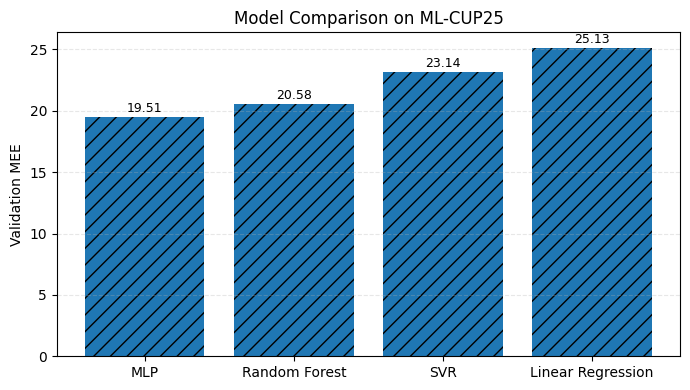

In [11]:
rf_params_df = pd.DataFrame([rf_grid.best_params_])
svr_params_df = pd.DataFrame([svr_grid.best_params_])
mlp_params_df = pd.DataFrame([mlp_grid.best_params_])

print("Best Random Forest Parameters")
display(rf_params_df)

print("Best SVR Parameters")
display(svr_params_df)

print("Best MLP Parameters")
display(mlp_params_df)

plt.figure(figsize=(7, 4))

bars = plt.bar(
    final_comparison_df["Model"],
    final_comparison_df["Validation MEE"],
    hatch='//'
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylabel("Validation MEE")

plt.title("Model Comparison on ML-CUP25")

plt.grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "model_comparison.png"
    ),
    dpi=300
)

plt.show()

## 9. Final Model Evaluation

In [12]:
from sklearn.base import clone

evaluation_model = clone(selected_model_config)

evaluation_model.fit(X_train, Y_train)

best_cv_scores = {
    "Linear Regression": linear_cv_mee,
    "SVR": -svr_grid.best_score_,
    "Random Forest": -rf_grid.best_score_,
    "MLP": -mlp_grid.best_score_,
}

best_cv_stds = {
    "Linear Regression": linear_cv_std,
    "SVR": svr_cv_std,
    "Random Forest": rf_cv_std,
    "MLP": mlp_cv_std,
    
}

train_m = mee(
    Y_train,
    evaluation_model.predict(X_train)
)

val_m = mee(
    Y_val,
    evaluation_model.predict(X_val)
)

test_m = mee(
    Y_test,
    evaluation_model.predict(X_test)
)

print("===== FINAL MODEL PERFORMANCE =====")

print(f"Selected Model: {best_model_name}")

print(f"Train MEE: {train_m:.4f}")
print(f"Validation MEE: {val_m:.4f}")
print(f"Test MEE: {test_m:.4f}")

print(
    f"CV MEE: "
    f"{best_cv_scores[best_model_name]:.4f}" 
)

print(
    f"CV STD: "
    f"{best_cv_stds[best_model_name]:.4f}" 
)


===== FINAL MODEL PERFORMANCE =====
Selected Model: MLP
Train MEE: 18.1102
Validation MEE: 19.5111
Test MEE: 20.7990
CV MEE: 22.1999
CV STD: 1.2925


Validation and test MEE remained relatively consistent, suggesting good generalization performance.

The gap between training and validation error was substantially smaller than the gap observed for Random Forest, indicating improved regularization behavior.

In [13]:
summary_df = pd.DataFrame([
    {
        "Model": best_model_name,
        "Train MEE": train_m,
        "Validation MEE": val_m,
        "Test MEE": test_m,
        "CV MEE": best_cv_scores[best_model_name],
        "CV STD": best_cv_stds[best_model_name]
    }
])

display(summary_df)

,Model,Train MEE,Validation MEE,Test MEE,CV MEE,CV STD
0,MLP,18.1102,19.5111,20.7990,22.1999,1.2925


## Overfitting Analysis

Random Forest achieved very low training error but substantially higher validation error, indicating severe overfitting behavior.

In contrast, the selected MLP maintained a smaller train-validation gap while preserving strong predictive performance.

The use of L2 regularization and early stopping contributed to improved generalization stability.

## 10. Learning Curve

We analyze model behavior with increasing training size.

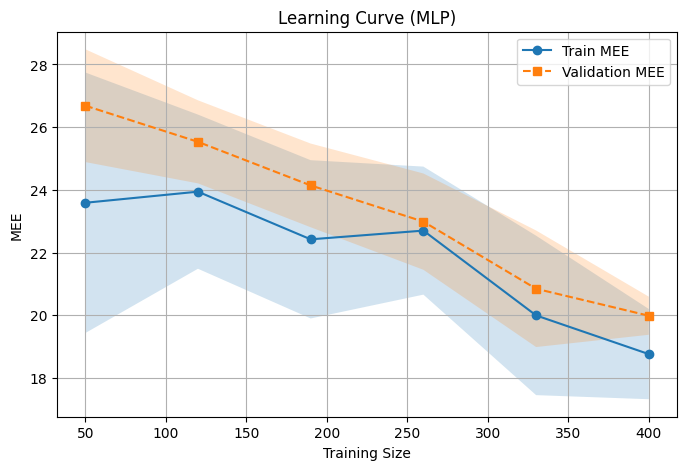

In [14]:
from sklearn.base import clone

rng = np.random.default_rng(42)

# Evaluate model behavior with progressively larger training subsets
train_sizes = np.linspace(
    50,
    len(X_train),
    6,
    dtype=int
)

train_mean = []
val_mean = []

train_std = []
val_std = []

n_repeats = 5

for size in train_sizes:

    train_scores = []
    val_scores = []

    for _ in range(n_repeats):

        idx = rng.choice(
            len(X_train),
            size=size,
            replace=False
        )

        model = clone(evaluation_model)

        model.fit(
            X_train[idx],
            Y_train[idx]
        )

        train_scores.append(
            mee(
                Y_train[idx],
                model.predict(X_train[idx])
            )
        )

        val_scores.append(
            mee(
                Y_val,
                model.predict(X_val)
            )
        )

    train_mean.append(
        np.mean(train_scores)
    )

    val_mean.append(
        np.mean(val_scores)
    )

    train_std.append(
        np.std(train_scores)
    )

    val_std.append(
        np.std(val_scores)
    )

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    linestyle='-',
    label="Train MEE"
)

plt.fill_between(
    train_sizes,
    np.array(train_mean) - np.array(train_std),
    np.array(train_mean) + np.array(train_std),
    alpha=0.2
)

plt.plot(
    train_sizes,
    val_mean,
    marker='s',
    linestyle='--',
    label="Validation MEE"
)

plt.fill_between(
    train_sizes,
    np.array(val_mean) - np.array(val_std),
    np.array(val_mean) + np.array(val_std),
    alpha=0.2
)

plt.xlabel("Training Size")
plt.ylabel("MEE")

plt.title(
    f"Learning Curve ({best_model_name})"
)

plt.grid(True)
plt.legend()

plt.savefig(
    os.path.join(
        results_dir,
        "cup_learning_curve.png"
    ),
    dpi=300
)

plt.show()


The learning curve shows that validation error gradually decreases as the number of training samples increases, indicating improved generalization capability with additional data.

Training and validation curves remain relatively close throughout the experiment, suggesting that the selected MLP configuration avoids severe overfitting.

The decreasing validation trend also suggests that additional training data could further improve predictive performance for the ML-CUP25 task.

## 11. Prediction Analysis

We visualize predicted vs true values.

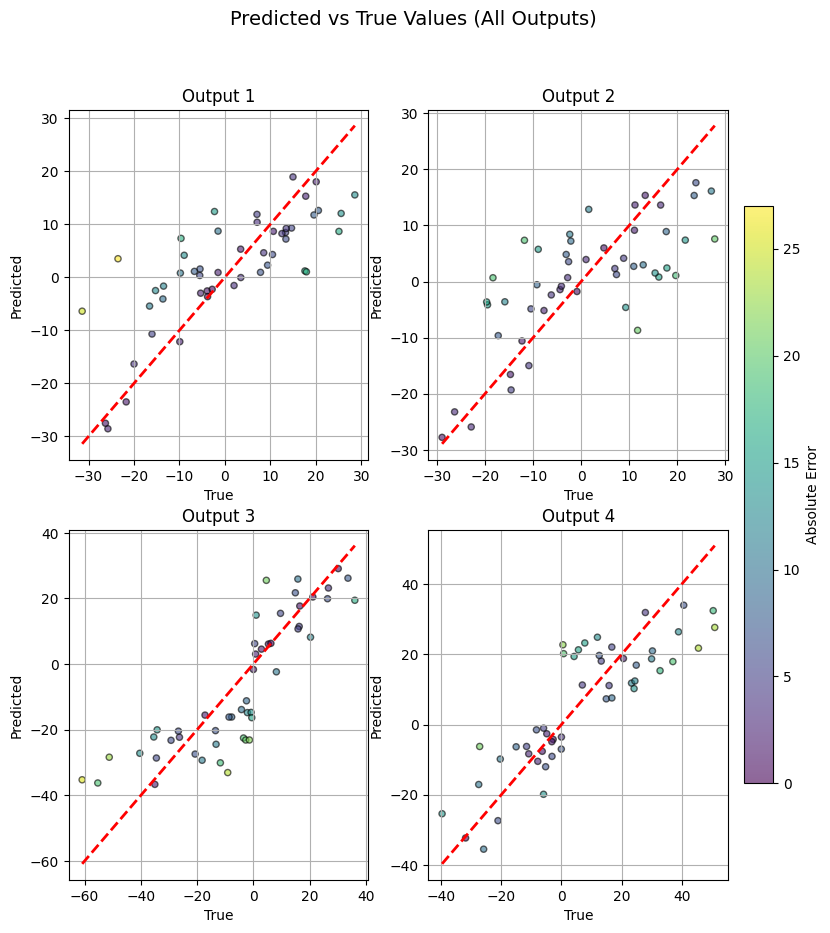

In [15]:
Y_val_real = Y_val

pred_real = evaluation_model.predict(X_val)

n_outputs = Y_val_real.shape[1]

all_errors = np.abs(
    Y_val_real - pred_real
)

vmin = 0
vmax = np.max(all_errors)

# Create one subplot for each target dimension
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 10)
)

axes = axes.flatten()

for i in range(n_outputs):

    ax = axes[i]

    errors = np.abs(
        Y_val_real[:, i] - pred_real[:, i]
    )

    sc = ax.scatter(
        Y_val_real[:, i],
        pred_real[:, i],
        c=errors,
        vmin=vmin,
        vmax=vmax,
        alpha=0.6,
        edgecolors='k',
        s=20
    )

    min_val = min(
        Y_val_real[:, i].min(),
        pred_real[:, i].min()
    )

    max_val = max(
        Y_val_real[:, i].max(),
        pred_real[:, i].max()
    )

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--',
        linewidth=2
    )

    ax.set_title(f"Output {i+1}")

    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")

    ax.grid(True)

plt.suptitle(
    "Predicted vs True Values (All Outputs)",
    fontsize=14,
    x=0.47
)

fig.subplots_adjust(
    right=0.92,
    top=0.88
)

cbar = fig.colorbar(
    sc,
    ax=axes,
    shrink=0.75,
    pad=0.02
)

cbar.set_label("Absolute Error")

plt.savefig(
    os.path.join(
        results_dir,
        "pred_vs_true_all_outputs.png"
    ),
    dpi=300
)

plt.show()

Most predictions lie reasonably close to the diagonal reference line, indicating that the model captured the overall regression structure.

Outputs 3 and 4 show slightly larger dispersion and higher prediction difficulty compared to Outputs 1 and 2.

## 11.1 Per-Output Error Analysis

,Output,Mean Absolute Error
0,Output 1,7.6139
1,Output 2,9.0262
2,Output 3,10.2724
3,Output 4,10.2757


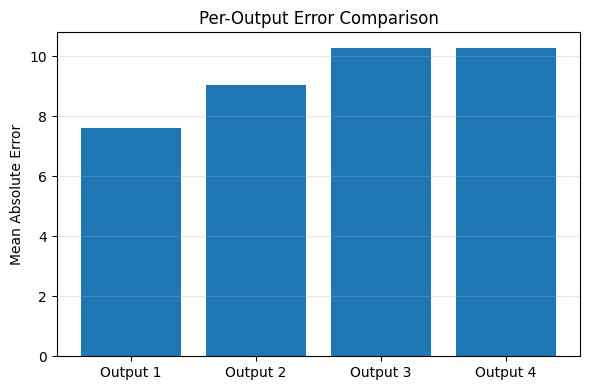

In [16]:
per_output_errors = []

pred_test = evaluation_model.predict(X_test)

for i in range(Y_test.shape[1]):

    mae = np.mean(
        np.abs(
            Y_test[:, i] - pred_test[:, i]
        )
    )

    per_output_errors.append({
        "Output": f"Output {i+1}",
        "Mean Absolute Error": mae
    })

per_output_df = pd.DataFrame(
    per_output_errors
)

pd.options.display.float_format = '{:.4f}'.format

display(per_output_df)

plt.figure(figsize=(6, 4))

plt.bar(
    per_output_df["Output"],
    per_output_df["Mean Absolute Error"]
)

plt.ylabel("Mean Absolute Error")

plt.title("Per-Output Error Comparison")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "per_output_error.png"
    ),
    dpi=300
)

plt.show()

Outputs 1 and 2 achieved lower MAE values, while Outputs 3 and 4 showed higher prediction difficulty.

This suggests heterogeneous complexity across target dimensions.

## 11.2 Residual error distribution

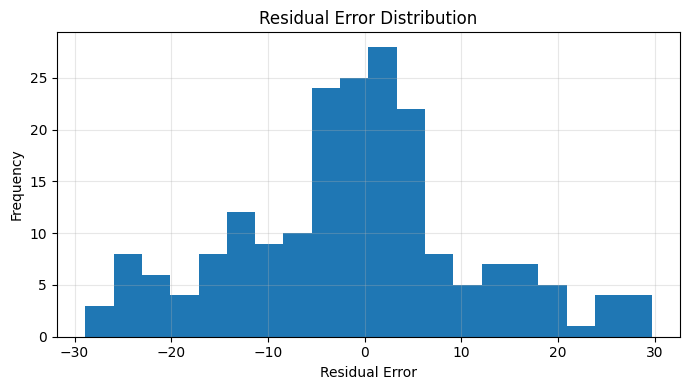

In [17]:
residuals = Y_test - pred_test

plt.figure(figsize=(7, 4))

plt.hist(
    residuals.flatten(),
    bins=20
)

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.title("Residual Error Distribution")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "residual_distribution.png"
    ),
    dpi=300
)

plt.show()

## 12. Feature Importance

Permutation importance on validation set.

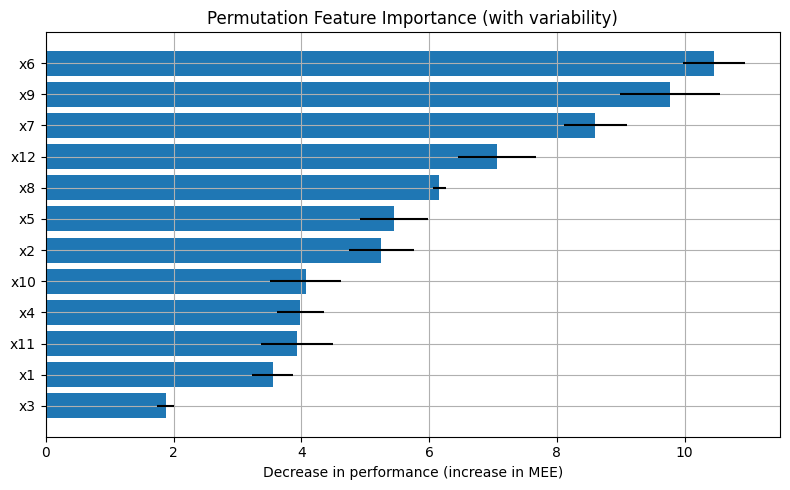

In [18]:
from sklearn.inspection import permutation_importance

n_repeats_outer = 5

all_importances = []

# Repeat importance computation across multiple random seeds
for seed in range(n_repeats_outer):

    perm = permutation_importance(
        evaluation_model,
        X_val,
        Y_val,
        scoring=mee_scorer,
        n_repeats=5,
        random_state=42 + seed,
        n_jobs=-1
    )

    all_importances.append(
        perm.importances_mean
    )

all_importances = np.array(all_importances)

importances_mean = np.mean(
    all_importances,
    axis=0
)

importances_std = np.std(
    all_importances,
    axis=0
)

indices = np.argsort(importances_mean)

plt.figure(figsize=(8, 5))

plt.barh(
    range(len(indices)),
    importances_mean[indices],
    xerr=importances_std[indices]
)

plt.yticks(
    range(len(indices)),
    [f"x{i}" for i in indices + 1]
)

plt.xlabel(
    "Decrease in performance (increase in MEE)"
)

plt.title(
    "Permutation Feature Importance (with variability)"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "feature_importance_improved.png"
    ),
    dpi=300
)

plt.show()

Permutation importance analysis showed that predictive information was concentrated in a subset of variables.

Features producing the largest increase in MEE after permutation contributed most strongly to model performance, while several remaining variables produced comparatively small MEE changes, suggesting lower predictive relevance or partial redundancy.

## 13. Final Training

After final model selection, the selected model was retrained on the full labeled dataset in order to maximize the information available for generating blind test predictions.

The reported Train, Validation, and Test MEE values were computed using the original 80/10/10 split. Retraining on the complete dataset before generating blind test predictions is standard practice because it allows the final deployed model to exploit all available labeled information.

The internal test set was not used during model selection or hyperparameter optimization and therefore remained an independent estimate of generalization performance throughout development.


In [19]:
start = time.time()

# Retrain selected model using all available labeled data
final_submission_model = clone(selected_model_config)

final_submission_model.fit(X, Y)

end = time.time()

print("\n===== FINAL MODEL SELECTION SUMMARY =====")
print(f"Selected Model    : {best_model_name}")
print(f"Selection Basis   : Best 5-fold Cross-Validation MEE")
print(f"Retrained on      : Full dataset ({X.shape[0]} samples)")
print(f"Blind Test File   : KathiriyaKhalid_ML-CUP25-TS.csv")
print(f"Training time     : {end - start:.2f} seconds")
print(f"Hardware          : CPU only, standard desktop")

print("Training time:", end - start)


===== FINAL MODEL SELECTION SUMMARY =====
Selected Model    : MLP
Selection Basis   : Best 5-fold Cross-Validation MEE
Retrained on      : Full dataset (500 samples)
Blind Test File   : KathiriyaKhalid_ML-CUP25-TS.csv
Training time     : 4.78 seconds
Hardware          : CPU only, standard desktop
Training time: 4.784316062927246


## 13.1 Computational Considerations and Execution Environment

MLP and Random Forest required the highest computational cost during grid search due to repeated cross-validation training.

SVR also became computationally expensive because a separate regressor was trained for each output dimension.

Linear Regression required the lowest computational cost.

In [20]:
time_df = pd.DataFrame({
    "Model": ["Random Forest", "MLP", "SVR"],
    "Grid Search Time (sec)": [
        rf_time,
        mlp_time,
        svr_time
    ]
})

display(time_df)

,Model,Grid Search Time (sec)
0,Random Forest,98.2146
1,MLP,23.3948
2,SVR,0.3220


## 14. Blind Test Prediction Generation

We generate predictions for the blind test set.

In [21]:
predictions = final_submission_model.predict(X_test_blind)

print(predictions.shape)

submission_file = os.path.join(
    results_dir,
    "KathiriyaKhalid_ML-CUP25-TS.csv"
)

# Generate blind test prediction file in official CUP format
with open(
    submission_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# Nandani Kathiriya, Laiba Khalid\n"
    )

    f.write("# KathiriyaKhalid\n")

    f.write("# ML-CUP25 v1\n")

    for i, row in enumerate(
        predictions,
        start=1
    ):

        f.write(
            f"{i},{row[0]:.6f},{row[1]:.6f},"
            f"{row[2]:.6f},{row[3]:.6f}\n"
        )

print(
    "Submission file saved:",
    submission_file
)

(1000, 4)
Submission file saved: c:\Users\PRENEEL\Desktop\ML-2025\ML-2025\results\cup\KathiriyaKhalid_ML-CUP25-TS.csv


## 15. Abstract

In [22]:
abstract_file = os.path.join(
    results_dir,
    "KathiriyaKhalid_abstract.txt"
)

with open(
    abstract_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
    "This project investigated the ML-CUP25 multi-output regression task using machine learning models implemented with scikit-learn. "
    "Linear Regression, SVR, Random Forest, and Multi-Layer Perceptron (MLP) models were compared using 5-fold cross-validation and Mean Euclidean Error (MEE). "
    "The final selected model was an MLP with hidden-layer architecture (250, 300, 200), L2 regularization (alpha = 0.001), learning rate initialization 0.01, and early stopping enabled. "
    "Hyperparameter optimization was performed using GridSearchCV on the training set, while validation and isolated internal test sets were used for secondary generalization analysis. "
    "The final selected MLP achieved the strongest balance between predictive accuracy and generalization performance and was retrained on the complete labeled dataset before blind test prediction generation."
)

print(
    "Abstract file saved:",
    abstract_file
)

Abstract file saved: c:\Users\PRENEEL\Desktop\ML-2025\ML-2025\results\cup\KathiriyaKhalid_abstract.txt


In [23]:
final_summary_df = pd.DataFrame([
    {
        "Selected Model": best_model_name,
        "Train MEE": train_m,
        "Validation MEE": val_m,
        "Test MEE": test_m,
        "CV MEE": best_cv_scores[best_model_name],
        "CV STD": best_cv_stds[best_model_name],
        "Training Time (sec)": end - start
    }
])

display(final_summary_df)

,Selected Model,Train MEE,Validation MEE,Test MEE,CV MEE,CV STD,Training Time (sec)
0,MLP,18.1102,19.5111,20.7990,22.1999,1.2925,4.7843


## 16. Final Conclusions

This project addressed the ML-CUP25 multi-output regression problem using a structured machine learning workflow including preprocessing, baseline comparison, hyperparameter optimization, validation, and final evaluation.

The relatively small dataset size (500 samples) represented an important limitation and likely contributed to the observed cross-validation variability.

Multiple regression models were evaluated, including Linear Regression, SVR, Random Forest, and MLP. Model selection was primarily based on 5-fold cross-validation performance while ensuring that the hold-out test set remained completely isolated during model development.

Among the evaluated approaches, MLP achieved the strongest balance between predictive accuracy, robustness, and validation performance.

The final selected model achieved:

* Selected Model: MLP
* Train MEE: 18.1102
* Validation MEE: 19.5111
* Test MEE: 20.7990
* CV MEE: 22.1999
* CV STD: 1.2925

The selected MLP generalized better than Random Forest and SVR, although cross-validation variability indicated moderate sensitivity to fold composition due to the relatively small dataset size.

The use of nonlinear modeling, L2 regularization, and early stopping helped improve prediction stability while limiting severe overfitting behavior.

The observed cross-validation variability reflects the sensitivity of model performance to fold composition effects within relatively small datasets, which is common in practical machine learning problems with limited training samples.

Although predictive performance could potentially be improved through more extensive hyperparameter optimization or larger training datasets, the experiments demonstrate that neural-network-based regression models can effectively model complex nonlinear multi-output regression tasks when combined with appropriate preprocessing and validation procedures.

Overall, the project showed the importance of model comparison, validation strategy, overfitting analysis, and hyperparameter tuning in practical machine learning tasks.